<a href="https://colab.research.google.com/github/encen-ya/PCVK_Genap2026/blob/main/Week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktukum Filter

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

In [17]:
def convolution2d(image, kernel, stride, padding):
    # Add padding to the input image
    img_padded = np.pad(image, padding, mode='constant', constant_values=0)

    # Get dimensions of image and kernel
    img_h, img_w = image.shape
    kernel_h, kernel_w = kernel.shape

    # Calculate output dimensions
    out_h = int((img_h - kernel_h + 2 * padding) / stride) + 1
    out_w = int((img_w - kernel_w + 2 * padding) / stride) + 1

    # Initialize output image
    output = np.zeros((out_h, out_w))

    # Perform 2D convolution
    for y in range(0, out_h):
        for x in range(0, out_w):
            # Extract the region of interest
            roi = img_padded[y*stride:y*stride+kernel_h, x*stride:x*stride+kernel_w]
            # Element-wise multiplication and summation
            output[y, x] = np.sum(roi * kernel)

    return output

In [12]:
#image sharpen
kernel_sharpen = np.array([[0, -1, 0],
                         [-1, 5, -1],
                         [0, -1, 0]])



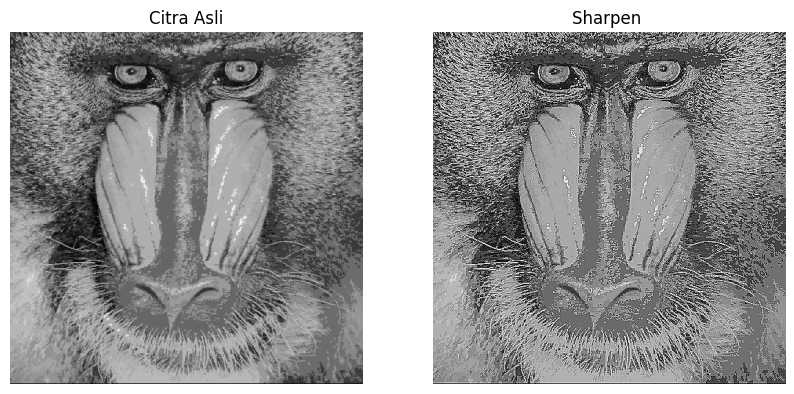

In [27]:
# Definisi Kernel Sharpen
kernel_sharpen = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])

# Terapkan filter dan tampilkan
res_sharpen = cv.filter2D(img_gray, -1, kernel_sharpen)

plt.figure(figsize=(10, 5))

# Gambar Asli
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Citra Asli')
plt.axis('off')

#sharpen
plt.subplot(1, 2, 2)
plt.imshow(res_sharpen, cmap='gray')
plt.title('Sharpen ')
plt.axis('off')

plt.show()

### 1. Emboss, Left Sobel Edge Detection, & Laplacian Edge Detection (Canny-like Edge Kernel)

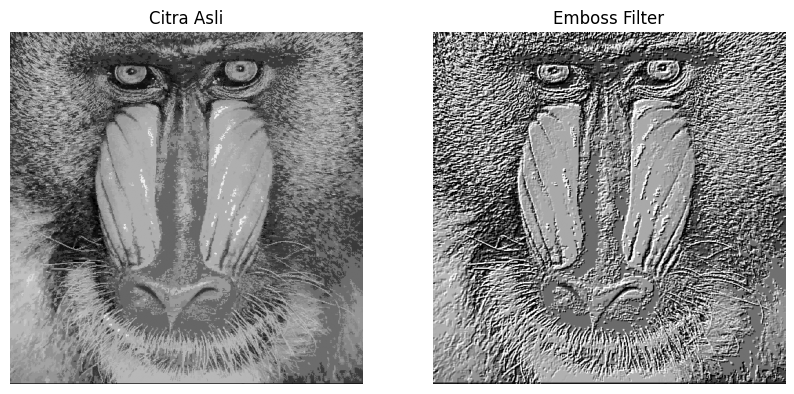

In [26]:
# Kernel Emboss
kernel_emboss = np.array([[-2, -1, 0],
                          [-1, 1, 1],
                          [0, 1, 2]])

res_emboss = cv.filter2D(img_gray, -1, kernel_emboss)

plt.figure(figsize=(10,5))

#citra asli
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Citra Asli')
plt.axis('off')

#emboss
plt.subplot(1, 2, 2)
plt.imshow(res_emboss, cmap='gray')
plt.title('Emboss Filter')
plt.axis('off')
plt.show()

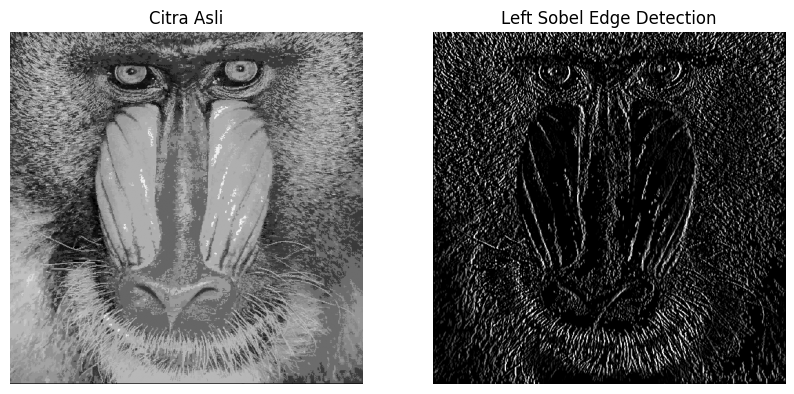

In [28]:
#Kernel Left Sobel Edge Detection
kernel_left_sobel = np.array([[1, 0, -1],
                              [2, 0, -2],
                              [1, 0, -1]])

res_sobel = cv.filter2D(img_gray, -1, kernel_left_sobel)

plt.figure(figsize=(10,5))

#citra asli
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Citra Asli')
plt.axis('off')

#left sobel
plt.subplot(1, 2, 2)
plt.imshow(res_sobel, cmap='gray')
plt.title('Left Sobel Edge Detection')
plt.axis('off')
plt.show()

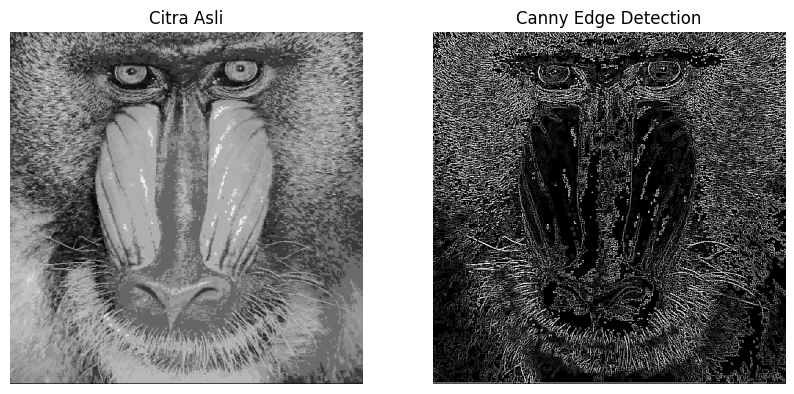

In [30]:
# Kernel Canny Edge Detection
kernel_canny = np.array([[-1, -1, -1],
                         [-1, 8, -1],
                         [-1, -1, -1]])

res_canny = cv.filter2D(img_gray, -1, kernel_canny)

#citra asli
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Citra Asli')
plt.axis('off')

#canny edge
plt.subplot(1, 2, 2)
plt.imshow(res_canny, cmap='gray')
plt.title('Canny Edge Detection')
plt.axis('off')
plt.show()

### 2. 21x21 Gaussian Blur

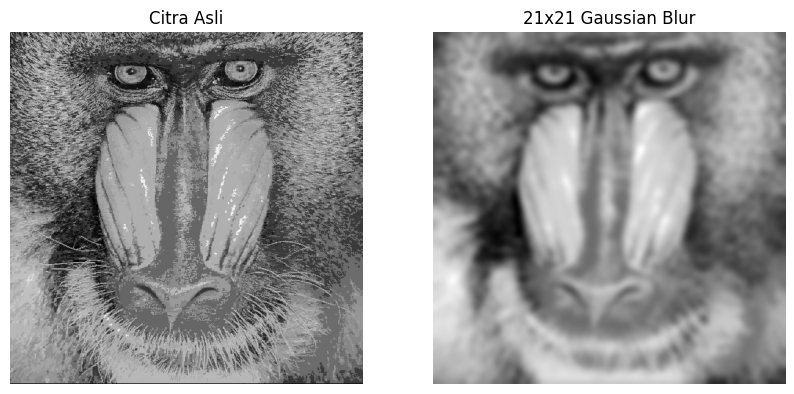

In [31]:
# Generate Kernel 21x21 Gaussian Blur
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_1d_kernel = cv.getGaussianKernel(kernel_size, sigma)
kernel_gaussian = gaussian_1d_kernel @ gaussian_1d_kernel.transpose()

res_gaussian = cv.filter2D(img_gray, -1, kernel_gaussian)

#citra asli
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Citra Asli')
plt.axis('off')

#gaussian blur
plt.subplot(1, 2, 2)
plt.imshow(res_gaussian, cmap='gray')
plt.title('21x21 Gaussian Blur')
plt.axis('off')
plt.show()

# E. FILTER LIBRARY DAN FILTER MODERN
## Percobaan 1

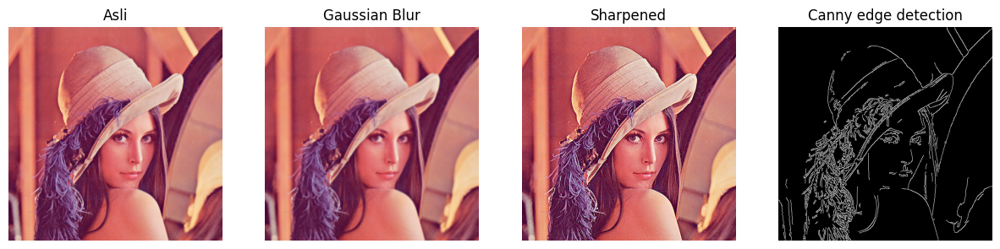

In [37]:
#Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15,5)):
  plt.figure(figsize=figsize)
  for i, (img,title) in enumerate(zip(images, titles)):
    if len(img.shape) == 2:
      plt.subplot(1, len(images), i+1)
      plt.imshow(img, cmap='gray')
    else:
      plt.subplot(1, len(images), i+1)
      plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
  plt.show()

img = cv.imread( '/content/drive/MyDrive/PCVK/Images/lena.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7, 7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img, blur, sharpened, edges],
                  ['Asli', 'Gaussian Blur', 'Sharpened', 'Canny edge detection'])


# Percobaan 2

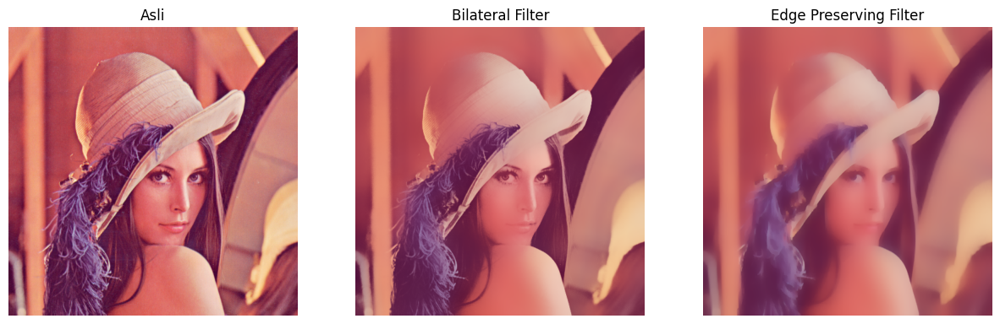

In [43]:
#Filter Modern dari OpenCV

bilateral = cv.bilateralFilter(img, 50, 100, 100)


edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
                  ['Asli', 'Bilateral Filter', 'Edge Preserving Filter'])

# Percobaan 3

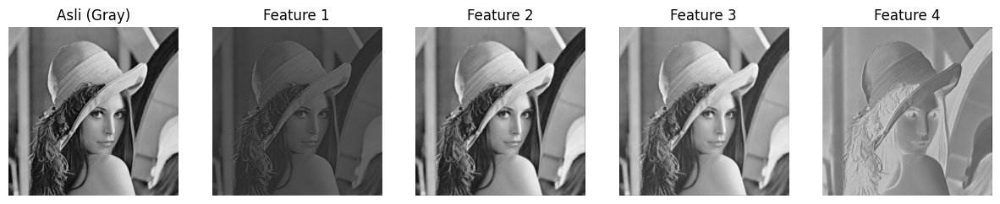

In [46]:
#Filter Feature Map yang digunakan pada CNN, Lakukan running code bagian ini beberapa kali dan perhatikan hasilnya
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [features[0, i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

# Percobaan 4

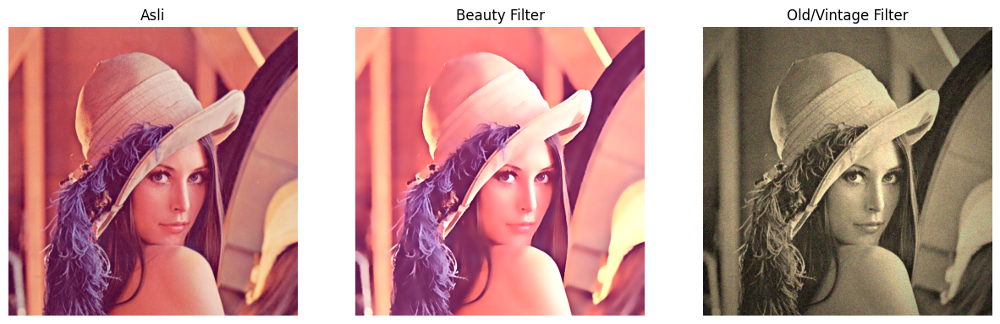

In [51]:
#1. Beauty Filter
# ====================
#Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)
#Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)
# Step 3: Brightness & contrast
alpha = 1.2 # contrast
beta = 15 # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

#2. Old/Vintage Filter
# ====================
#Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

#Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

show_side_by_side([img, beauty, old_img],
                  ["Asli", "Beauty Filter", "Old/Vintage Filter"])

# Percoban 5

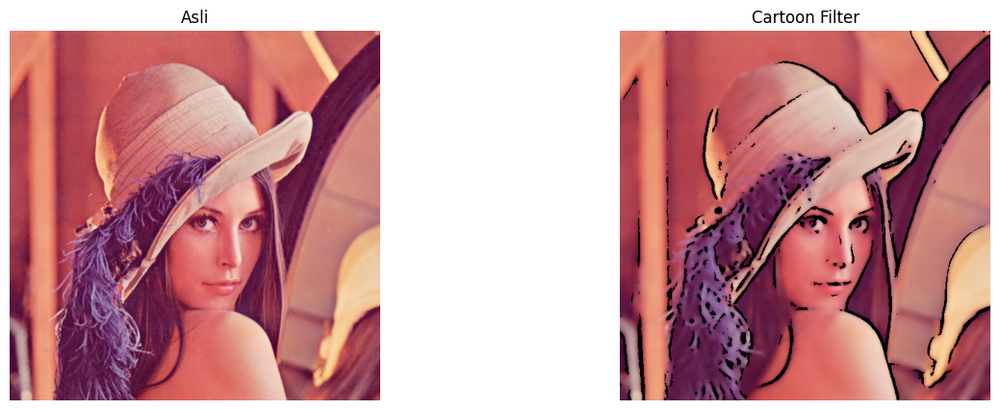

In [48]:
#Filter Anime / Cartoon
#Step 1: Edge detection (pakai median blur dulu agar gambar menjadi lebih halus)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 9, 9)

#Step 2: Bilateral Filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

#Step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

# Percobaan 6

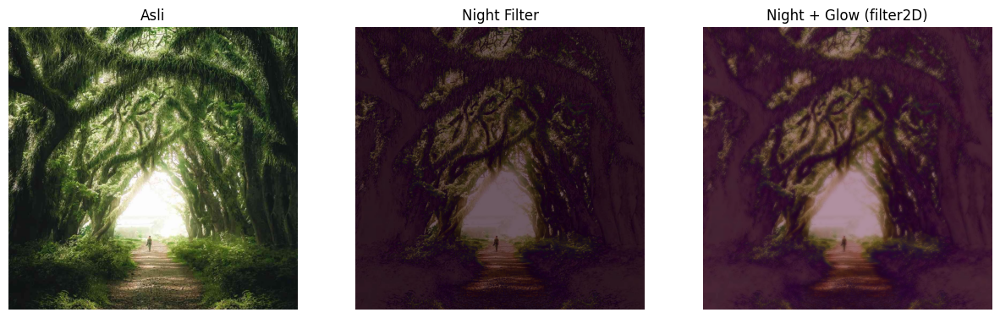

In [54]:
#Night Filter
img = cv.imread("/content/drive/MyDrive/PCVK/Images/djawatan.jpg")
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

#Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

#Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100)) # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

#Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15,15), np.float32)/225
glow = cv.filter2D(night, -1, kernel)

#Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.9, 0)

show_side_by_side([img, night, night_glow], ["Asli", "Night Filter", "Night + Glow (filter2D)"])

# Percobaan 7

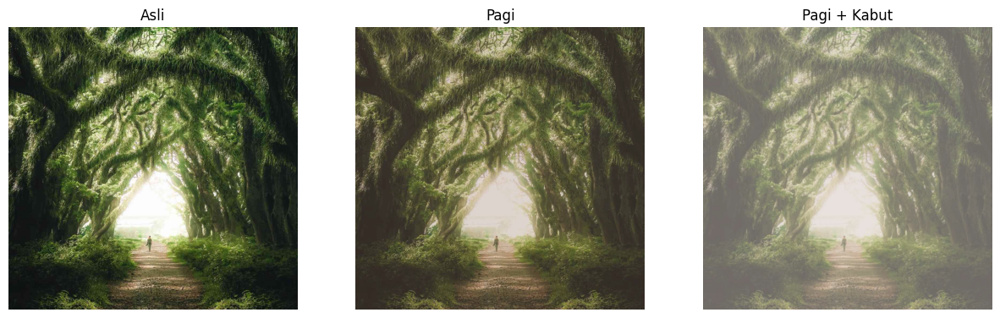

In [55]:
#Filter Suasana pagi dan Kabut

alpha = 0.9 # contrast
beta = 20 # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# Step 2: Tambahkan warm tone (kemerahan / oranye)
warm_tint = np.full_like(soft, (40, 70, 120)) # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)


# Step 3: Tambahkan haze (kabut tipis) dengan filter2D

# Kernel blur Gaussian-like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut], ["Asli", "Pagi", "Pagi + Kabut"])

# Tugas Praktikum

# 1

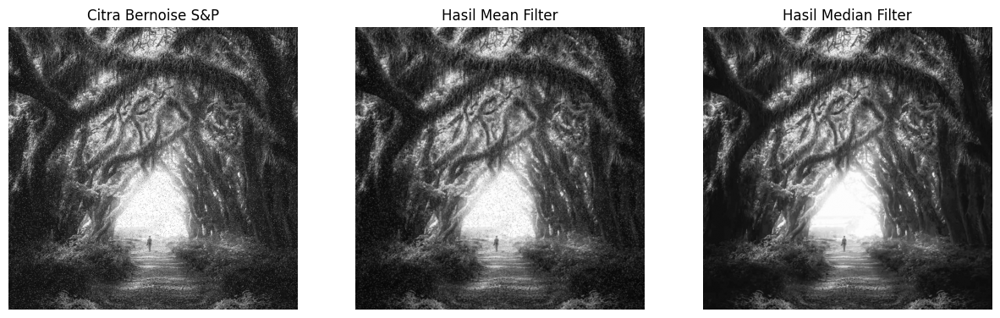

In [56]:
import random

# a. Fungsi untuk menambahkan noise Salt and Pepper
def add_salt_and_pepper_noise(image, prob=0.05):
    noisy = np.copy(image)
    # Tambah Salt (Putih)
    num_salt = np.ceil(prob * image.size * 0.5)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy[tuple(coords)] = 255
    # Tambah Pepper (Hitam)
    num_pepper = np.ceil(prob * image.size * 0.5)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy[tuple(coords)] = 0
    return noisy

# Terapkan noise pada citra grayscale
img_noisy = add_salt_and_pepper_noise(img_gray, prob=0.05)

# b. Terapkan Mean Filter dan Median Filter (ukuran 3x3)
mean_filtered = cv.blur(img_noisy, (3, 3))
median_filtered = cv.medianBlur(img_noisy, 3)

# Tampilkan hasil secara berdampingan
show_side_by_side([img_noisy, mean_filtered, median_filtered],
                  ['Citra Bernoise S&P', 'Hasil Mean Filter', 'Hasil Median Filter'], figsize=(15,5))

## Analisis Visual (Jawaban poin 1.c):
### Median filter jauh lebih bersih dalam menghapus noise salt and pepper karena cara kerjanya mengambil nilai tengah (median) dari piksel tetangga, sehingga noise (yang berupa nilai ekstrem 0 atau 255) akan diabaikan dan digantikan dengan piksel asli di sekitarnya. Sebaliknya, Mean Filter merata-ratakan seluruh nilai piksel tetangga termasuk noise ekstrem tersebut. Hal ini menyebabkan titik noise tidak sepenuhnya hilang, melainkan hanya menyebar, sehingga gambar terlihat kabur dan bercak-bercak noise masih terlihat.

# 2

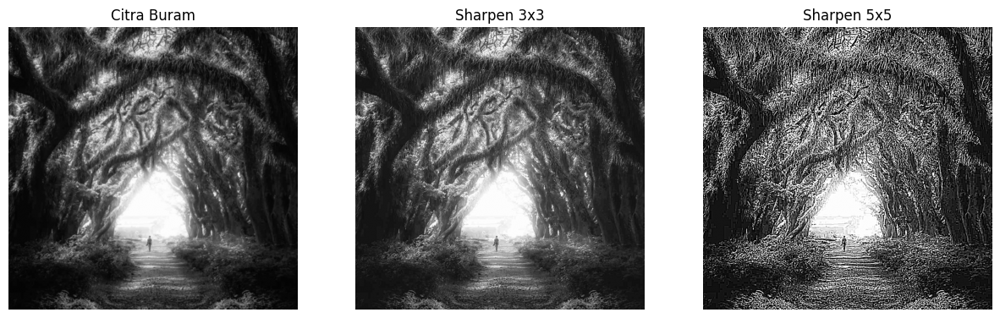

In [57]:
# Buat citra sedikit buram terlebih dahulu (blurry image)
img_blurry = cv.GaussianBlur(img_gray, (5, 5), 0)

# a. Buat kernel sharpening ukuran 3x3 dan 5x5
kernel_sharpen_3x3 = np.array([[ 0, -1,  0],
                               [-1,  5, -1],
                               [ 0, -1,  0]])

kernel_sharpen_5x5 = np.array([[-1, -1, -1, -1, -1],
                               [-1, -1, -1, -1, -1],
                               [-1, -1, 25, -1, -1],
                               [-1, -1, -1, -1, -1],
                               [-1, -1, -1, -1, -1]])

# b. Terapkan kernel pada citra yang sedikit buram
res_sharpen_3x3 = cv.filter2D(img_blurry, -1, kernel_sharpen_3x3)
res_sharpen_5x5 = cv.filter2D(img_blurry, -1, kernel_sharpen_5x5)

# Tampilkan Hasil
show_side_by_side([img_blurry, res_sharpen_3x3, res_sharpen_5x5],
                  ['Citra Buram', 'Sharpen 3x3', 'Sharpen 5x5'], figsize=(15,5))

## Evaluasi (Jawaban poin 2.c):

### Kejelasan Tepi vs Noise: Kernel 3x3 menajamkan tepi dengan cukup baik tanpa menaikkan terlalu banyak noise di area yang datar. Sementara itu, kernel 5x5 memberikan efek penajaman yang jauh lebih agresif dan sangat kontras pada tepi, tetapi ia juga sangat memperkuat noise (titik-titik kasar akan terlihat sangat jelas pada gambar), menyebabkan noise distortion yang tinggi.

### Kesimpulan Kernel Optimal: Untuk penggunaan sehari-hari, kernel ukuran 3x3 adalah yang paling optimal. Ia memberikan keseimbangan (balance) yang baik antara mengembalikan detail yang buram tanpa merusak kualitas citra akibat noise amplification.

# Tugas 3: Kreasi Filter Kartun Sederhana

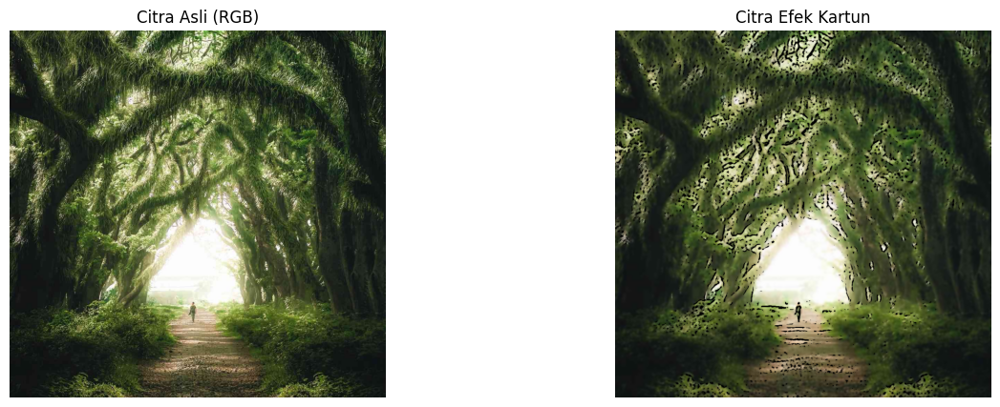

In [58]:
# a. Membuat fungsi kustom kartun(image)
def kartun(image):
    # 1. Penghalusan warna menggunakan Bilateral Filter
    # Parameter d, sigmaColor, sigmaSpace dikonfigurasi cukup tinggi agar warna tampak rata (kartun)
    color = cv.bilateralFilter(image, d=9, sigmaColor=200, sigmaSpace=200)

    # 2. Deteksi garis tepi menggunakan Adaptive Thresholding
    # Ubah gambar asli ke grayscale dan gunakan median blur untuk melembutkan tepi
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    gray_blur = cv.medianBlur(gray, 7)

    # Deteksi tepi menggunakan adaptive threshold
    edges = cv.adaptiveThreshold(gray_blur, 255,
                                 cv.ADAPTIVE_THRESH_MEAN_C,
                                 cv.THRESH_BINARY, 9, 9)

    # 3. Penggabungan (kombinasi) warna halus dan garis tepi
    cartoon = cv.bitwise_and(color, color, mask=edges)

    return cartoon

# Panggil fungsi pada citra warna asli
hasil_kartun = kartun(img)

# b. Tampilkan hasil citra asli dengan citra efek kartun bersebelahan
show_side_by_side([img, hasil_kartun], ['Citra Asli (RGB)', 'Citra Efek Kartun'])